In [ ]:
import scanpy as sc
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse
sc.set_figure_params(dpi=80)

In [ ]:
import importlib.util
import sys

def lazy_import(module_name, path_to_file):
    spec = importlib.util.spec_from_file_location(module_name,path_to_file)
    foo = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = foo
    spec.loader.exec_module(foo)
    return foo

utils_dir = "../../utils"
general_utils =  lazy_import("general_utils",os.path.join(utils_dir, "general_utils.py"))
anndata_utils = lazy_import("anndata_utils",os.path.join(utils_dir, "anndata_utils.py"))
diffusion_maps = lazy_import("diffusion_maps",os.path.join(utils_dir, "diffusion_maps.py"))

from general_utils import ismember, grep
from anndata_utils import marker_genes_for_cell_group
from diffusion_maps import plot_diffusion_components


### Diffusion component analysis

In [ ]:
def DC_heatmap(adata_sub, ranking_vector, nbins = 50, CORRELATION_THRESHOLD = 0.8, vmin = -1, vmax = 1):
    adata_sub.layers['zscore'] = adata_sub.X.copy()
    sc.pp.scale(adata_sub, layer='zscore')
    
    ordering = np.argsort(ranking_vector)
    adata_temp = adata_sub[ordering,:].copy()
    df = pd.DataFrame(adata_temp.layers['zscore'], columns = adata_temp.var_names)
    binsize = df.shape[0]/nbins
    df['bin'] = (df.index.to_numpy() / binsize).astype(np.uint16)
    df = df.groupby('bin').agg('mean').iloc[:-1,]

    xval = list(range(df.shape[0]))
    correlations = []
    pval = []
    for i in range(df.shape[1]):
        result = scipy.stats.spearmanr(xval, df.iloc[:,i].to_numpy())
        correlations.append(result.statistic)
        pval.append(result.pvalue)
    corr_stats = pd.DataFrame({'statistic': correlations, 'pval': pval}, index = df.columns)

    ordering = np.argsort(corr_stats['statistic'].to_numpy())
    df = df.iloc[:,ordering].copy()
    corr_stats = corr_stats.iloc[ordering,:].copy()
    
    valid_genes = np.abs(corr_stats['statistic']) > CORRELATION_THRESHOLD

    selected_genes = corr_stats.index[valid_genes].to_numpy()
    df_temp = df.loc[:,selected_genes].copy()

    plt.figure()
    plt.imshow(df_temp.T, aspect='auto', interpolation = 'None', vmin = vmin, vmax = vmax, cmap = 'RdBu_r')
    #h = plt.yticks(range(len(selected_genes)), labels = [x.capitalize() for x in selected_genes])
    plt.grid(False)
    plt.colorbar(fraction = 0.025)

    return(df, df_temp)

def DC_signatures(adata_sub, selected_signatures, ranking_vector, nbins = 50, vmin = -1, vmax = 1):

    ordering = np.argsort(ranking_vector)
    adata_temp = adata_sub[ordering,:].copy()
    df = adata_sub.obs[selected_signatures].copy()
    df.index = range(df.shape[0])
    binsize = df.shape[0]/nbins
    df['bin'] = (df.index.to_numpy() / binsize).astype(np.uint16)
    df = df.groupby('bin').agg('mean').iloc[:-1,]
    
    plt.figure()
    plt.imshow(df.T, aspect='auto', interpolation = 'None', vmin = vmin, vmax = vmax, cmap = 'RdBu_r')
    #h = plt.yticks(range(len(selected_genes)), labels = [x.capitalize() for x in selected_genes])
    plt.grid(False)
    plt.colorbar(fraction = 0.025)

    return(df)

### Myeloid cells from FLEX, exclude RETNLA and PLAC8 populations

/data/lowe/reyesj3/miniconda3/envs/rapidsai/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


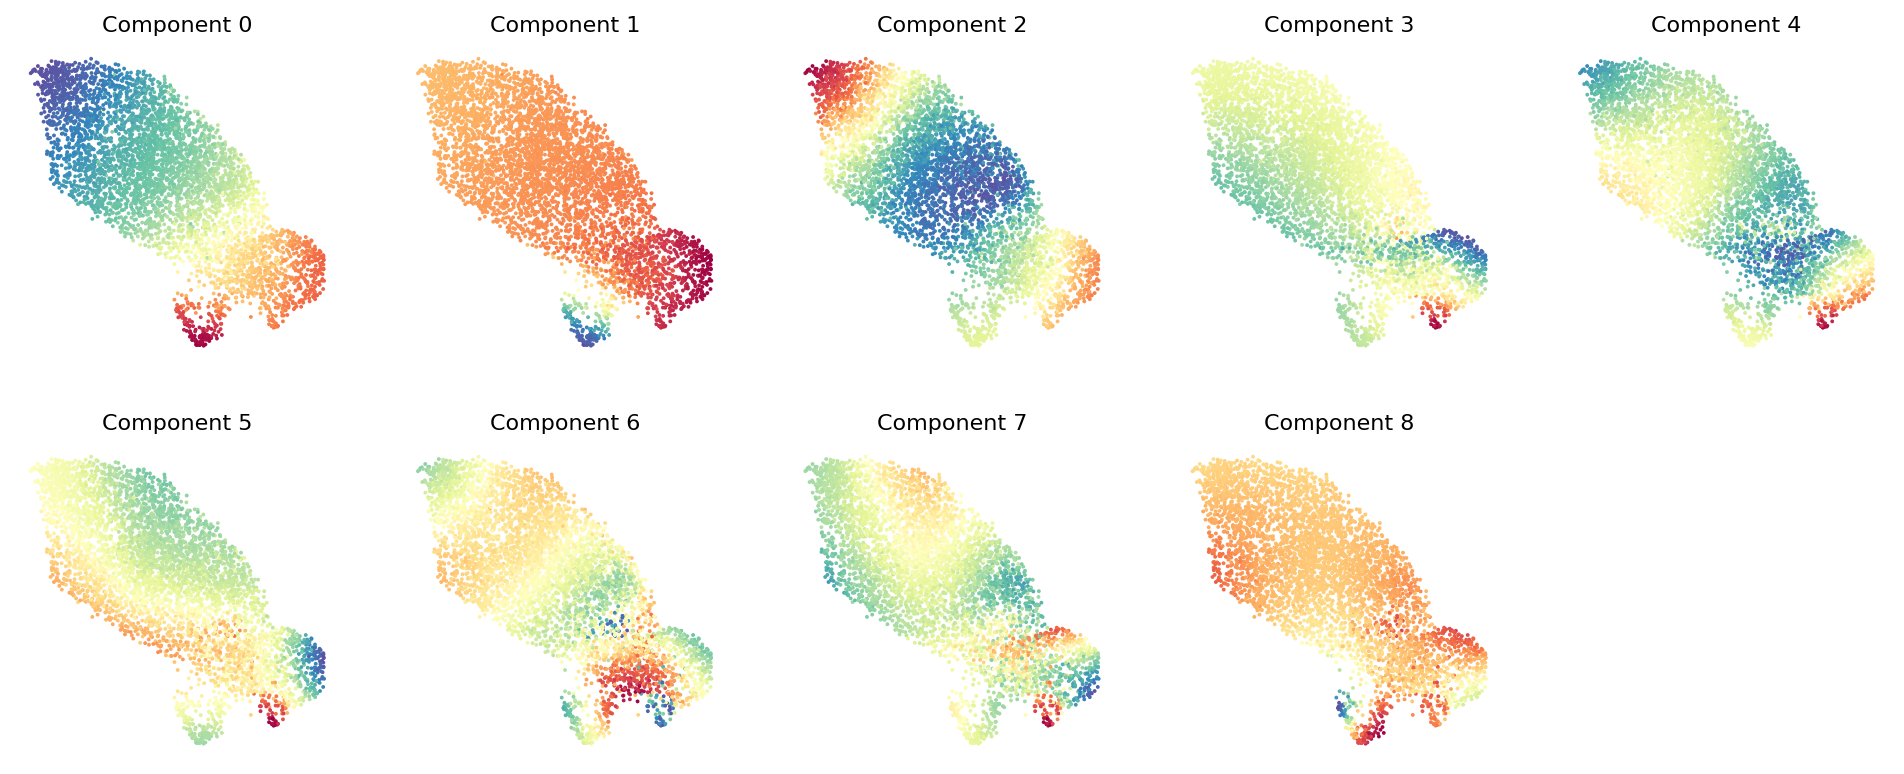

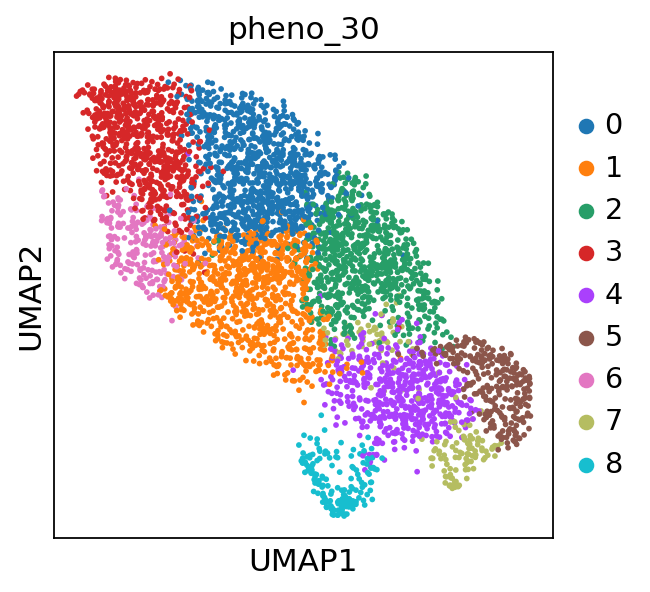

In [ ]:
adata_sub = sc.read_h5ad('../data/Reyes_FLEX_SUBSET_TAM_Maf_Itgax_SAMPLE_ctrl__integrated.h5ad')
adata_sub.obs['pheno_30'] = pd.Categorical(adata_sub.obs['pheno_30'])
adata_sub.obs['pheno_10'] = pd.Categorical(adata_sub.obs['pheno_10'])
plot_diffusion_components(adata_sub.obsm['X_umap'], adata_sub.obsm['X_diff_comp'])
sc.pl.umap(adata_sub, color='pheno_30')

In [ ]:
subcells = ismember(adata_sub.obs['pheno_30'], np.unique(adata_sub.obs['pheno_30']))[1]
ranking_vector = adata_sub.obsm['X_diff_comp'][:,0].copy()

/data/lowe/reyesj3/repositories/temp/ipykernel_111393/305564441.py:2: ImplicitModificationWarning: Setting element `.layers['zscore']` of view, initializing view as actual.
  adata_sub.layers['zscore'] = adata_sub.X.copy()
/data/lowe/reyesj3/miniconda3/envs/rapidsai/lib/python3.9/site-packages/scipy/stats/_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Text(0.5, 1.0, 'Myeloid cells')

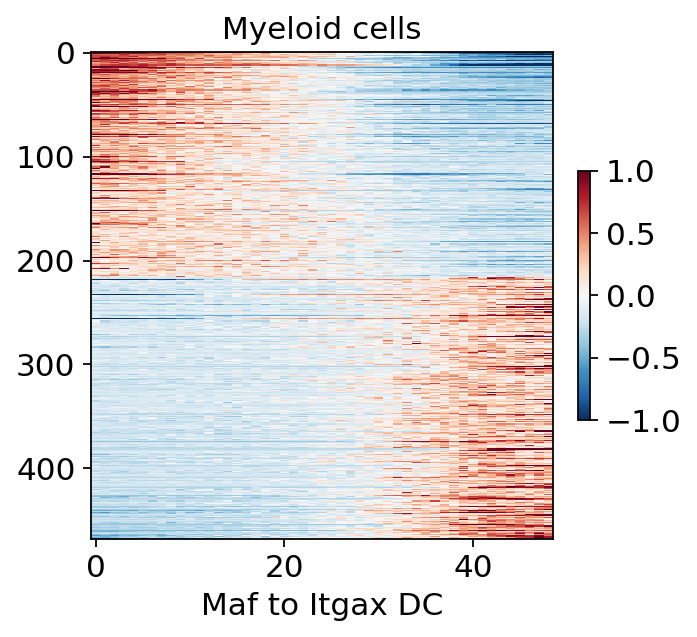

In [ ]:
df, df_temp = DC_heatmap(adata_sub[subcells,:], ranking_vector[subcells], nbins = 50, CORRELATION_THRESHOLD = 0.75)
plt.xlabel("Maf to Itgax DC")
plt.title("Myeloid cells")

In [ ]:
measurements_file = '../support/Fig20250408_MYELOID_gene_trends_NHOODMODE_circle60_neighborhood_agg.csv'
Xenium_myeloid_measured = pd.read_csv(measurements_file, index_col = 0)
Xenium_myeloid_measured = Xenium_myeloid_measured.index.to_numpy()

Text(0.5, 1.0, 'Myeloid cells')

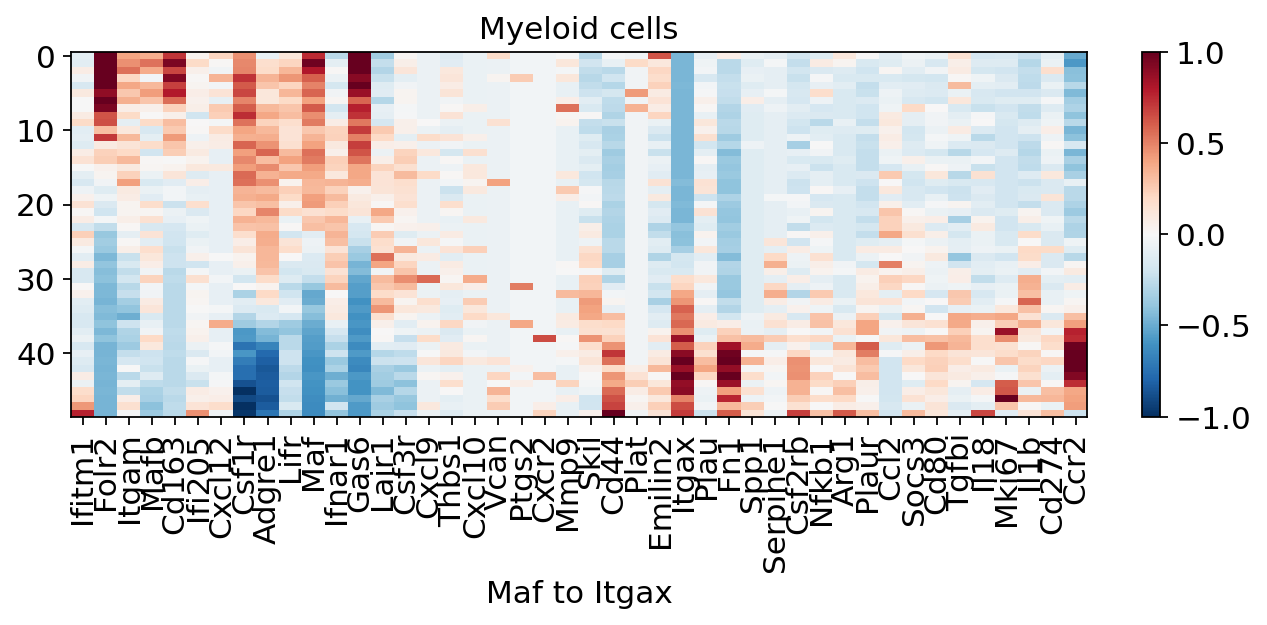

In [ ]:
# Curated genes are plotted in the order they appear in the Xenium main figure heatmap
curated_genes = [x.upper() for x in Xenium_myeloid_measured]

# Additional genes are plotted according to their position along the DC axis
new_genes = np.array(['CD80', 'FOLR2', 'IL1B', 'NFKB1', 'SPP1', 'FN1', 'THBS1', 'PTGS2','ARG1'])
new_genes = list(new_genes[np.logical_not(ismember(new_genes, curated_genes)[1])])
all_genes = np.array(curated_genes + new_genes)

# Get DC index of all genes
DC_ordering = np.argsort(ismember(all_genes, df.columns)[0])
all_genes = all_genes[DC_ordering]

# Replace DC ordering by fixed ordering from gastric-progenitor niche pseudotime
curated_positions = np.where(ismember(all_genes, curated_genes)[1])[0]
fixed_ordering = np.array(ismember(curated_genes, all_genes[ismember(all_genes, curated_genes)[1]])[0])
ordering = np.array(range(len(all_genes)))
ordering[curated_positions] = curated_positions[fixed_ordering]
all_genes = all_genes[ordering]

# Plot genes
plt.figure(figsize = [len(all_genes)*0.2, 3])
plt.imshow(df.loc[:,all_genes], aspect='auto', interpolation = 'None', vmin = -1, vmax = 1, cmap = 'RdBu_r')
h = plt.xticks(range(len(all_genes)), labels = [x.capitalize() for x in all_genes], rotation = 90)
plt.grid(False)
plt.colorbar(fraction = 0.025)

plt.xlabel("Maf to Itgax")
plt.title("Myeloid cells")


### Fibroblasts from FLEX, myCAF

/data/lowe/reyesj3/miniconda3/envs/rapidsai/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


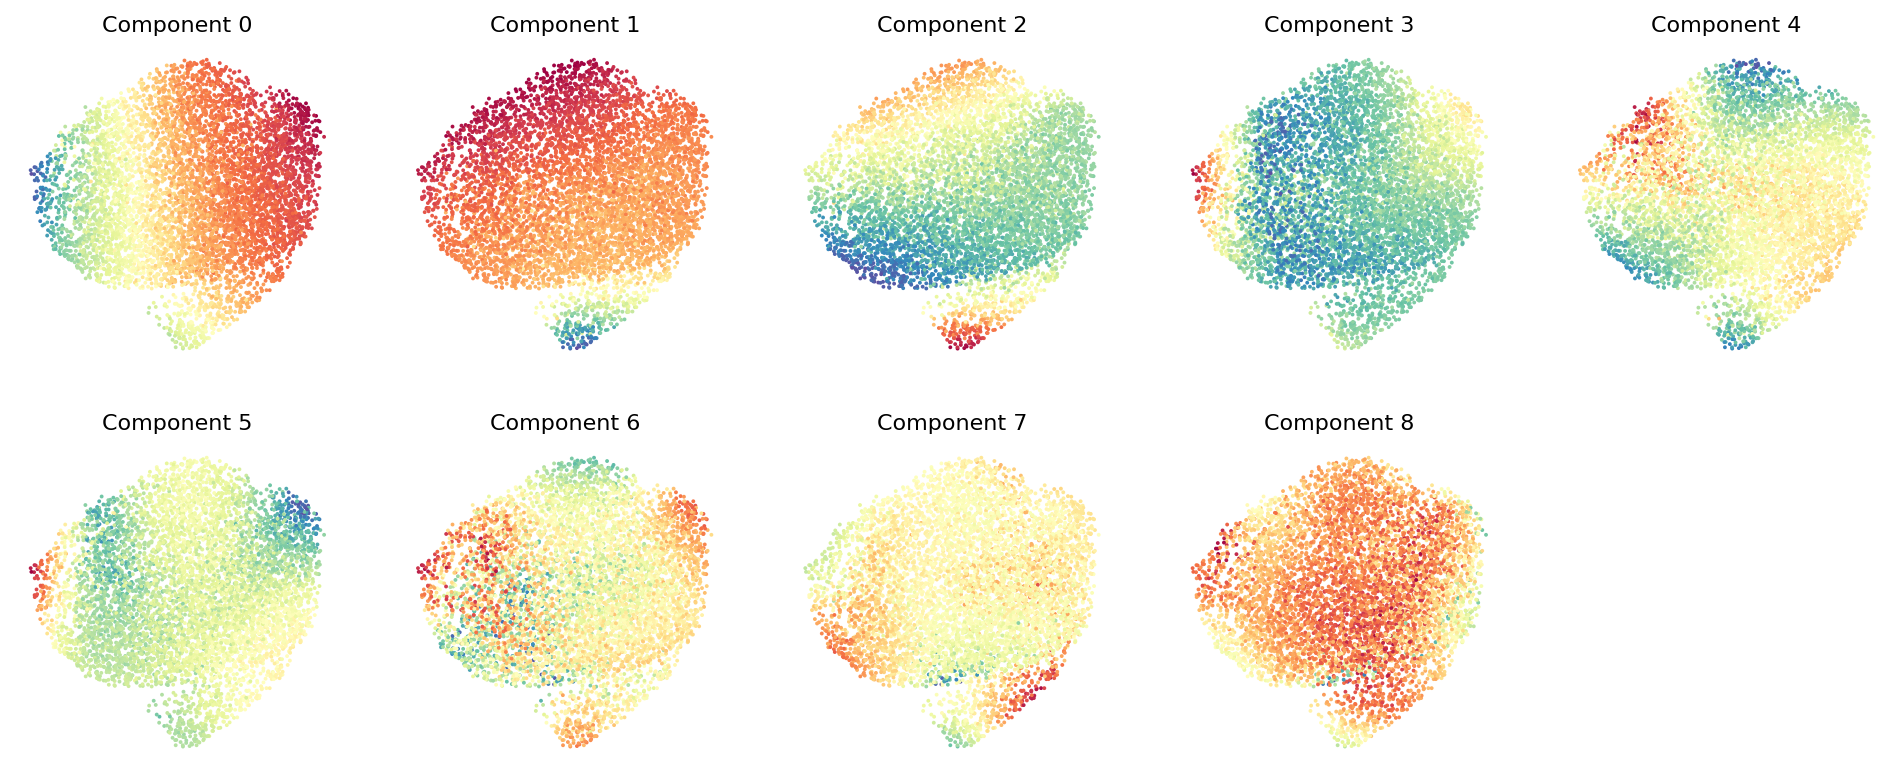

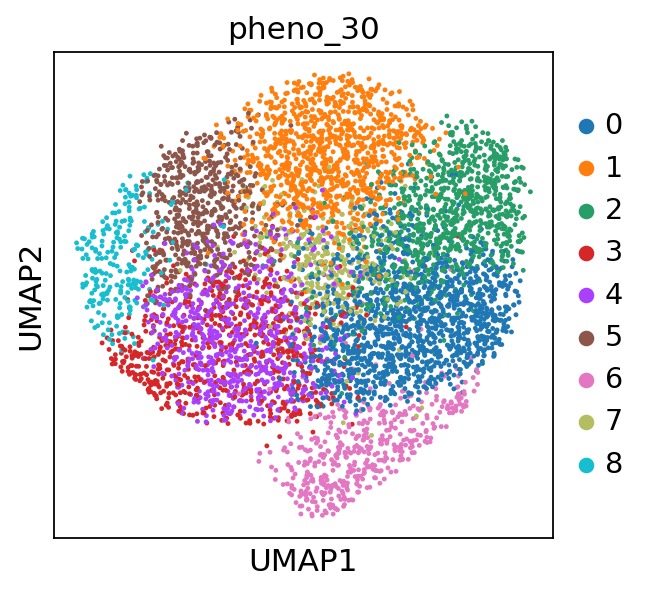

In [ ]:
adata_sub = sc.read_h5ad('../data/Reyes_FLEX_SUBSET_Fib_myCAF_SAMPLE_ctrl__integrated.h5ad')
adata_sub.obs['pheno_30'] = pd.Categorical(adata_sub.obs['pheno_30'])
adata_sub.obs['pheno_10'] = pd.Categorical(adata_sub.obs['pheno_10'])
plot_diffusion_components(adata_sub.obsm['X_umap'], adata_sub.obsm['X_diff_comp'])
sc.pl.umap(adata_sub, color='pheno_30')

In [ ]:
subcells = ismember(adata_sub.obs['pheno_30'], np.unique(adata_sub.obs['pheno_30']))[1]
ranking_vector = -adata_sub.obsm['X_diff_comp'][:,0].copy()

/data/lowe/reyesj3/repositories/temp/ipykernel_111393/305564441.py:2: ImplicitModificationWarning: Setting element `.layers['zscore']` of view, initializing view as actual.
  adata_sub.layers['zscore'] = adata_sub.X.copy()
/data/lowe/reyesj3/miniconda3/envs/rapidsai/lib/python3.9/site-packages/scipy/stats/_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


Text(0.5, 1.0, 'Fibroblasts cells')

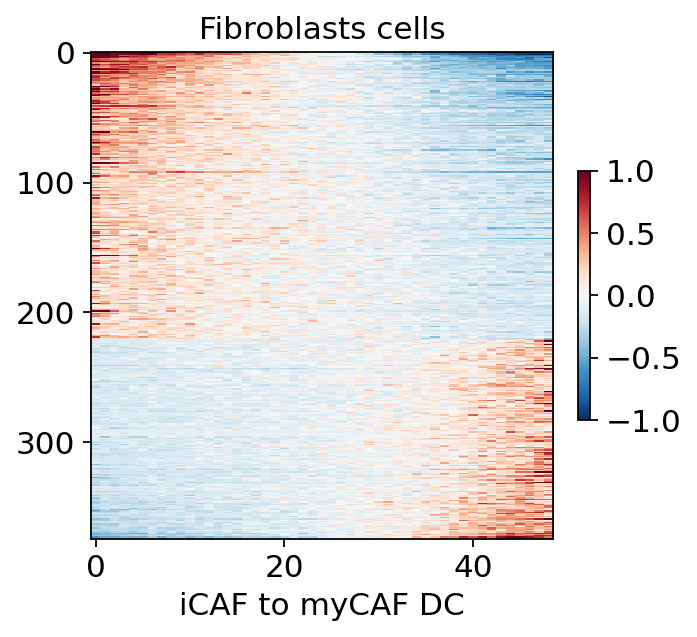

In [ ]:
df, df_temp = DC_heatmap(adata_sub[subcells,:], ranking_vector[subcells], nbins = 50, CORRELATION_THRESHOLD = 0.75)
plt.xlabel("iCAF to myCAF DC")
plt.title("Fibroblasts cells")

In [ ]:
measurements_file = '../support/Fig20250408_FIB_gene_trends_NHOODMODE_circle60_neighborhood_agg.csv'
Xenium_fibroblast_measured = pd.read_csv(measurements_file, index_col = 0)
Xenium_fibroblast_measured = Xenium_fibroblast_measured.index.to_numpy()

Text(0.5, 1.0, 'Fibroblasts')

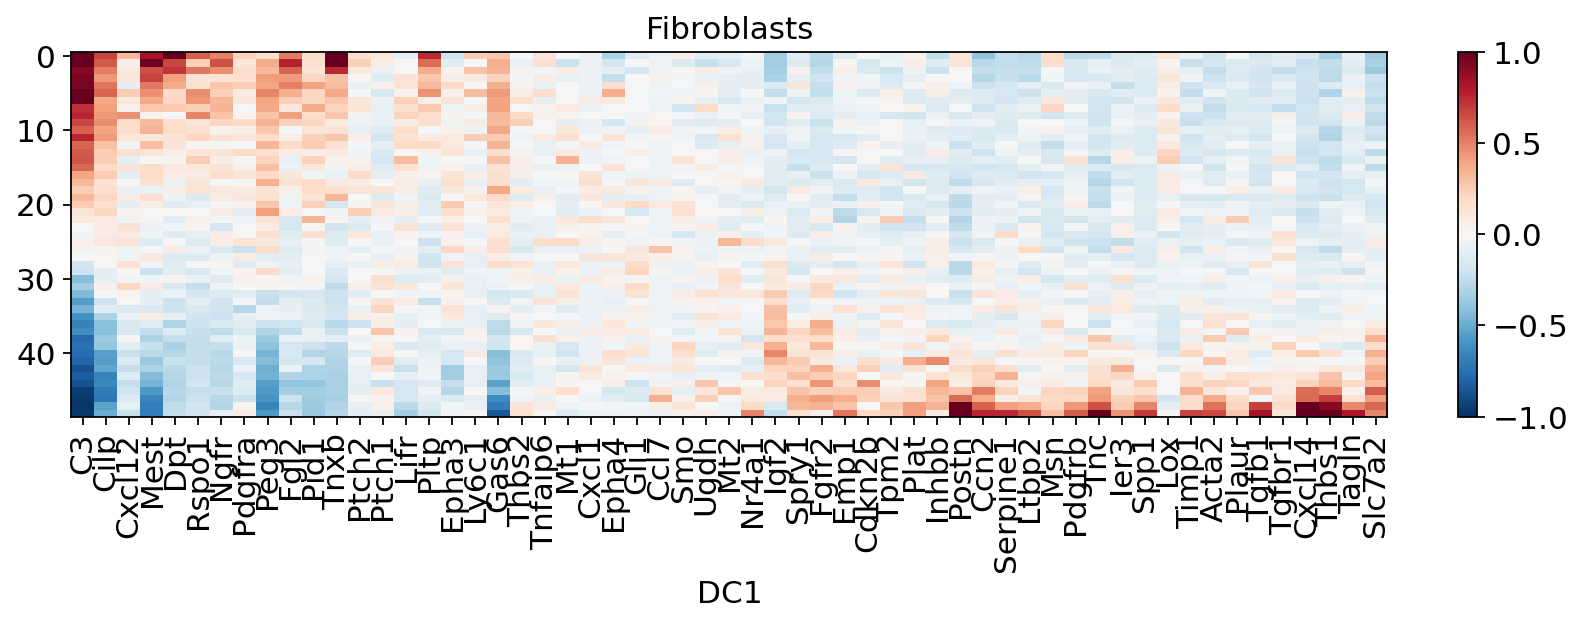

In [ ]:
# Curated genes are plotted in the order they appear in the Xenium main figure heatmap
curated_genes = [x.upper() for x in Xenium_fibroblast_measured]

# Additional genes are plotted according to their position along the DC axis
new_genes = np.array(['TNFAIP6', 'LY6C1', 'CXCL1', 'C3', 'CCL7', 'UGDH', 'MT1', 'MT2', 'MEST', 'PEG3', 'PID1', 'CILP', 'SLC7A2', 'TIMP1', 'ACTA2', 'PLTP', 'NR4A1', 'FGL2', 'IER3', 'CXCL14', 'SPP1', 'THBS1', 'THBS2', 'LTBP2', 'TPM2'])
new_genes = list(new_genes[np.logical_not(ismember(new_genes, curated_genes)[1])])
all_genes = np.array(curated_genes + new_genes)

# Get DC index of all genes
DC_ordering = np.argsort(ismember(all_genes, df.columns)[0])
all_genes = all_genes[DC_ordering]

# Replace DC ordering by fixed ordering from gastric-progenitor niche pseudotime
curated_positions = np.where(ismember(all_genes, curated_genes)[1])[0]
fixed_ordering = np.array(ismember(curated_genes, all_genes[ismember(all_genes, curated_genes)[1]])[0])
ordering = np.array(range(len(all_genes)))
ordering[curated_positions] = curated_positions[fixed_ordering]
all_genes = all_genes[ordering]

# Plot genes
plt.figure(figsize = [len(all_genes)*0.2, 3])
plt.imshow(df.loc[:,all_genes], aspect='auto', interpolation = 'None', vmin = -1, vmax = 1, cmap = 'RdBu_r')
h = plt.xticks(range(len(all_genes)), labels = [x.capitalize() for x in all_genes], rotation = 90)
plt.grid(False)
plt.colorbar(fraction = 0.025)

plt.xlabel("DC1")
plt.title("Fibroblasts")
